In [5]:
# Import libraries

import os
import numpy as np
import pandas as pd
import librosa
import seaborn as sns
from tqdm import tqdm  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb

np.random.seed(42)

In [6]:
# Load dataset

dataset_path = 'kaggle/input/Voice Emotion Dataset'

def load_dataset():
    data = []
    labels = []
    emotions = ['anger', 'neutral', 'sad']
    
    for emotion in emotions:
        emotion_path = os.path.join(dataset_path, emotion)
        if os.path.exists(emotion_path):
            for file in os.listdir(emotion_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(emotion_path, file)
                    data.append(file_path)
                    labels.append(emotion)
    
    return pd.DataFrame({'file_path': data, 'emotion': labels})

df = load_dataset()
print(f"Dataset loaded: {len(df)} samples")
print(f"Emotions distribution:\n{df['emotion'].value_counts()}")

Dataset loaded: 26545 samples
Emotions distribution:
emotion
anger      9315
sad        9315
neutral    7915
Name: count, dtype: int64


In [7]:
# Extract features from the recordings: mfccs, mfcc_mean, spectral_centroid (correlated with zero_crossing_rate and spectral_rolloff), chroma, rms, contrast

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        # try n_mfcc = 40
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfccs, axis=1)
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
        rms = np.mean(librosa.feature.rms(y=y))
        mfcc_delta = np.mean(librosa.feature.delta(mfccs))
        mfcc_delta2 = np.mean(librosa.feature.delta(mfccs, order=2))
        zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y))
        spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
                
        return {
            'spectral_centroid': spectral_centroid,
            'zero_crossing_rate': zero_crossing_rate,
            'spectral_rolloff': spectral_rolloff,
            'chroma': chroma,
            'contrast': contrast,
            'rms': rms,
            'mfcc_delta': mfcc_delta,
            'mfcc_delta2': mfcc_delta2,
            'mfcc_mean': np.mean(mfcc_mean)
        }
    except:
        return None

In [8]:
sample_df = df.sample(min(300, len(df))).copy() 
features_list = []
for idx, row in sample_df.iterrows():
    features = extract_features(row['file_path'])
    if features:
        features['emotion'] = row['emotion']
        features_list.append(features)

features_df = pd.DataFrame(features_list)

c:\Users\kosty\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [9]:
features_df.head()

,spectral_centroid,zero_crossing_rate,spectral_rolloff,chroma,contrast,rms,mfcc_delta,mfcc_delta2,mfcc_mean,emotion
0,3139.341344,0.313603,4992.555147,0.329063,27.258109,0.029285,0.035685,0.026491,-30.552389,anger
1,1427.756791,0.099240,2339.943910,0.234071,27.329451,0.011539,0.016537,-0.111723,-33.091015,sad
2,1564.386443,0.102976,3206.620066,0.410743,22.856911,0.005996,-0.054415,-0.006597,-25.144457,neutral
3,2268.366608,0.199287,3764.892578,0.283424,25.868220,0.017730,0.096890,0.000782,-27.703209,neutral
4,1617.906842,0.117778,2941.464552,0.245749,25.538357,0.034139,-0.015565,-0.022799,-22.033745,sad


Text(0.5, 1.0, 'Feature Correlation Matrix')

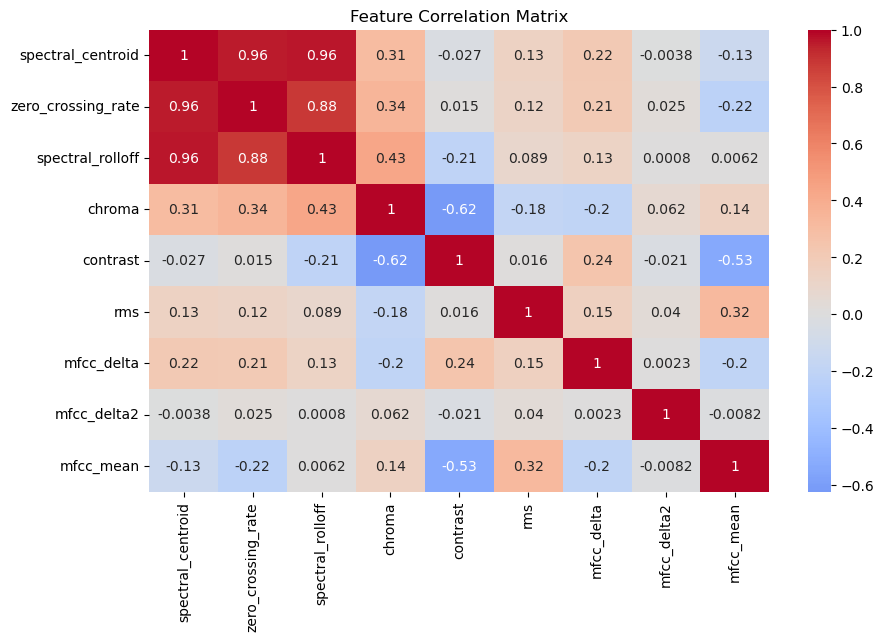

In [10]:
# Feature Correlation Matrix - zero_crossing_rate and spectral_rolloff are highly correlated with spectral_centroid

plt.figure(figsize=(10, 6))
numeric_features = features_df.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

In [11]:
# Prepare Dataset (delete zero_crossing_rate and spectral_rolloff from features because of high correlation with spectral_centroid)
X = features_df.drop(columns=['emotion', 'zero_crossing_rate'])
y = features_df['emotion']


# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [12]:
# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split to train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)

In [13]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning
xgb_params = {
    'n_estimators': [500, 550],
    'max_depth': [7, 10],
    'learning_rate': [0.2, 0.1]
}
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

rf_params = {
    'n_estimators': [200, 250],
    'max_depth': [10, 20]
}
rf_clf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_clf, rf_params, cv=3, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

c:\Users\kosty\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\kosty\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\kosty\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'n_estimators': [200, 250]},
             verbose=1)

In [14]:
# Final Ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_grid.best_estimator_),
        ('rf', rf_grid.best_estimator_)
    ],
    voting='soft'
)
ensemble_model.fit(X_train, y_train)

c:\Users\kosty\anaconda3\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learn...one,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None,
                                            objective='multi:softprob',
                                            predictor=None, ...)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42))],
                 voting='soft')

In [15]:
# Evaluation
y_pred = ensemble_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("🎯 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


✅ Test Accuracy: 0.7167
🎯 Classification Report:
              precision    recall  f1-score   support

       anger       0.90      0.82      0.86        22
     neutral       0.60      0.53      0.56        17
         sad       0.64      0.76      0.70        21

    accuracy                           0.72        60
   macro avg       0.71      0.70      0.71        60
weighted avg       0.72      0.72      0.72        60



In [ ]:
# Save model

import joblib

joblib.dump(ensemble_model, "emotion_recognition_model.pkl")

# To download the model later use: model = joblib.load("emotion_recognition_model.pkl")

['emotion_recognition_model.pkl']